# CMT Analysis

## Import Packages

In [1]:
import pandas as pd
import re
from functools import reduce
from spacy.tokenizer import Tokenizer
from spacy.lang.en import English
import nltk
from nltk.corpus import stopwords 
nlp = English()
tokenizer = Tokenizer(nlp.vocab)
import matplotlib.pyplot as plt

C:\Users\romha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Reading and Cleaning Data

### Metaphor Annotations

In [2]:
# load in CMT annotation json and save it to a pandas dataframe
file_path = 'CMT_Jan10.json'
met_df = pd.read_json(file_path)

# load in CMT sample annotation json and save it to a pandas dataframe
file_path_sample = 'CMTS_Jan10.json'
sample_met_df = pd.read_json(file_path_sample)


In [4]:
# COMBINING W SAMPLE
met_df = pd.concat([met_df, sample_met_df])
# extracting labels from the annotations column
met_df['labels'] = met_df.apply(lambda row: row.annotations[0]['result'], axis=1)

# cleaning up file names 
met_df['filename'] = met_df.apply(lambda row: re.sub(r"^[^_]*-", '', row.file_upload), axis=1)
met_df['filename'] = met_df.apply(lambda row: re.sub(r"_fixed", '', row.filename[:-4].lower()), axis=1)
met_df['filename'] = met_df.apply(lambda row: re.sub(r"aboriginal", 'indigenous', row.filename), axis=1)

In [5]:
# creating a dictionary of metaphor labels, where each key is a filename
met_labels = {}
for name in met_df['filename'].unique():
    # creating a new dataframe only containing labels corresponding to one file
    new_df = met_df[met_df['filename']==name][['filename', 'labels']].reset_index()
    # creating a list to save the labels in 
    labels_dic = {}
    for el in new_df['labels'][0]:
        # adding labels to the label list 
        if el['from_name']=='source':
            start = el['value']['start']
            end = el['value']['end']
            for source in el['value']['taxonomy'][0]:
                try: 
                    labels_dic[source].append([start,end])
                except KeyError: 
                    labels_dic[source] = [[start,end]]
    # saving the dic of labels to the dictionary of filenames
    met_labels[name] = labels_dic

## Corpus Analysis

In [6]:
# creating a new dataframe based on the metaphor dataframe, with fewer columns
df_analysis=met_df[['filename', 'data']]
# creating a column that measures the length of the text associated with each filename
df_analysis['length'] = df_analysis.apply(lambda row: len(tokenizer(row.data['text'])), axis=1)

C:\Users\romha\AppData\Local\Temp\ipykernel_38516\1368652667.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['length'] = df_analysis.apply(lambda row: len(tokenizer(row.data['text'])), axis=1)


In [7]:
# shortest comments
df_analysis.loc[(df_analysis.length == min(df_analysis.length))]

,filename,data,length
166,belgium_127,{'text': '!!!!!!!!!!!!!!'},1
309,china_39,{'text': 'LOL...!'},1
662,trump_38,{'text': 'Ha-Ha-Ha!!!'},1
855,watch_30,{'text': 'Baloney.'},1
859,watch_37,{'text': 'Exactly!'},1


In [8]:
# longest
df_analysis.loc[(df_analysis.length == max(df_analysis.length))]

,filename,data,length
826,uber_94,{'text': 'Uber drivers have filed a class acti...,793


In [11]:
# statistics
print('There are {} comments in the corpus. The comments range between {} and {} in number of tokens, with an average of {}. \
The total number of tokens in the corpus is {}.'.format(len(df_analysis), min(df_analysis.length), 
                                                        max(df_analysis.length), sum(df_analysis.length)/len(df_analysis), 
                                                        sum(df_analysis.length)))

There are 1043 comments in the corpus. The comments range between 1 and 793 in number of tokens, with an average of 62.21093000958773. The total number of tokens in the corpus is 64886.


In [10]:
# creating a list to contain the length of each label
# (the spans are not unique; so number of labels =/= number of metaphors) 
labels_diff = []
for all_labels in met_labels.values():
    for label in all_labels.values():
        for indices in label:
            # calculating the difference in indices
            length=indices[1]-indices[0]
            # appending the length to the list
            labels_diff.append(length)
print('There are {} labels in the CMT annotation layer, and the average span of each label is {} characters.'.format(len(labels_diff),
                                                                                                                    sum(labels_diff)/len(labels_diff)))

There are 4355 labels in the CMT annotation layer, and the average span of each label is 25.915958668197476 characters.


## Results

### Common Source Domains

In [15]:
# creating a list of all the potential sources
source_list = []
for file in met_labels.keys():
    source_list.extend(list(met_labels[file]))

In [16]:
def domain_counts(labels_dic):
    '''
    takes a dictionary of labels as input and returns a dataframe that has a label column, a count column, and a frequency column
    '''
    # creating a dictionary where every potential source is a key and setting the values to zero
    source_dic = {}
    for source in set(source_list):
        source_dic[source]=0
    # populating the dictionary by counting the number of occurences for each source
    for file in labels_dic.keys():
        # going through each source in the file's labels 
        for source in labels_dic[file].keys():
            # updating the count in the source dictionary
            source_dic[source] = source_dic[source] + len(labels_dic[file][source])
    source_count_df = pd.DataFrame(source_dic.items(), columns=['label','count'])
    total = source_count_df['count'].sum()
    source_count_df['frequency'] = source_count_df.apply(lambda row: int(row['count'])/total, axis=1)
    return source_count_df.sort_values(by='count', ascending=False)
#return sorted(source_dic.items(), key=lambda x: x[1], reverse=True)

In [17]:
# top sources overall
top_sources = domain_counts(met_labels)
top_sources.head(10)

,label,count,frequency
11,Container(s),303,0.069575
14,Transferring an Object,171,0.039265
93,Body,117,0.026866
197,Object(s),104,0.023881
192,Motion,104,0.023881
214,Competition,103,0.023651
116,Possession(s),99,0.022732
74,Physical Properties,90,0.020666
102,Game,87,0.019977
104,Constructed Object,86,0.019747


In [18]:
# list of topics
p = re.compile(r'\D*(?=_\d+)')
filename_topics = [p.match(name).group(0) for name in met_df.filename.values]
unique_topics = []
for topic in filename_topics:
    if topic not in unique_topics:
        unique_topics.append(topic) 

In [19]:
# counting labels by topic and creating a df
labels_by_topic = {}
count_df_by_topic = {}
for topic in unique_topics:
    labels_by_topic[topic]= dict(filter(lambda item: topic in item[0], met_labels.items()))
    count_df_by_topic[topic] = domain_counts(labels_by_topic[topic])

# rename columns by topic
for topic in count_df_by_topic.keys():
    count_df_by_topic[topic]=count_df_by_topic[topic].rename(columns={'count':f'{topic}_count','frequency':f'{topic}_frequency'})

# a list of the dataframes created for each topic
dataframes = [top_sources]
for topic in count_df_by_topic.keys():
    dataframes.append(count_df_by_topic[topic])

# joining all dataframes 
labels_over_all_topics = reduce(lambda  left,right: pd.merge(left,right,on=['label'], how='outer'), dataframes)

In [24]:
top10 = labels_over_all_topics.sort_values(by='count', ascending=False).head(10)#.plot()

In [27]:
p = re.compile(r'\D*_frequency')
freq_columns = [col for col in top10.columns if p.match(col)]

<Axes: xlabel='label'>

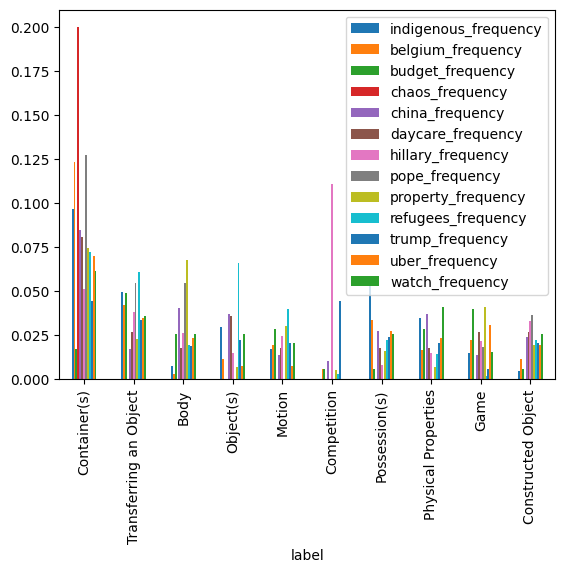

In [28]:
top10.plot(x='label',y=freq_columns,kind='bar')

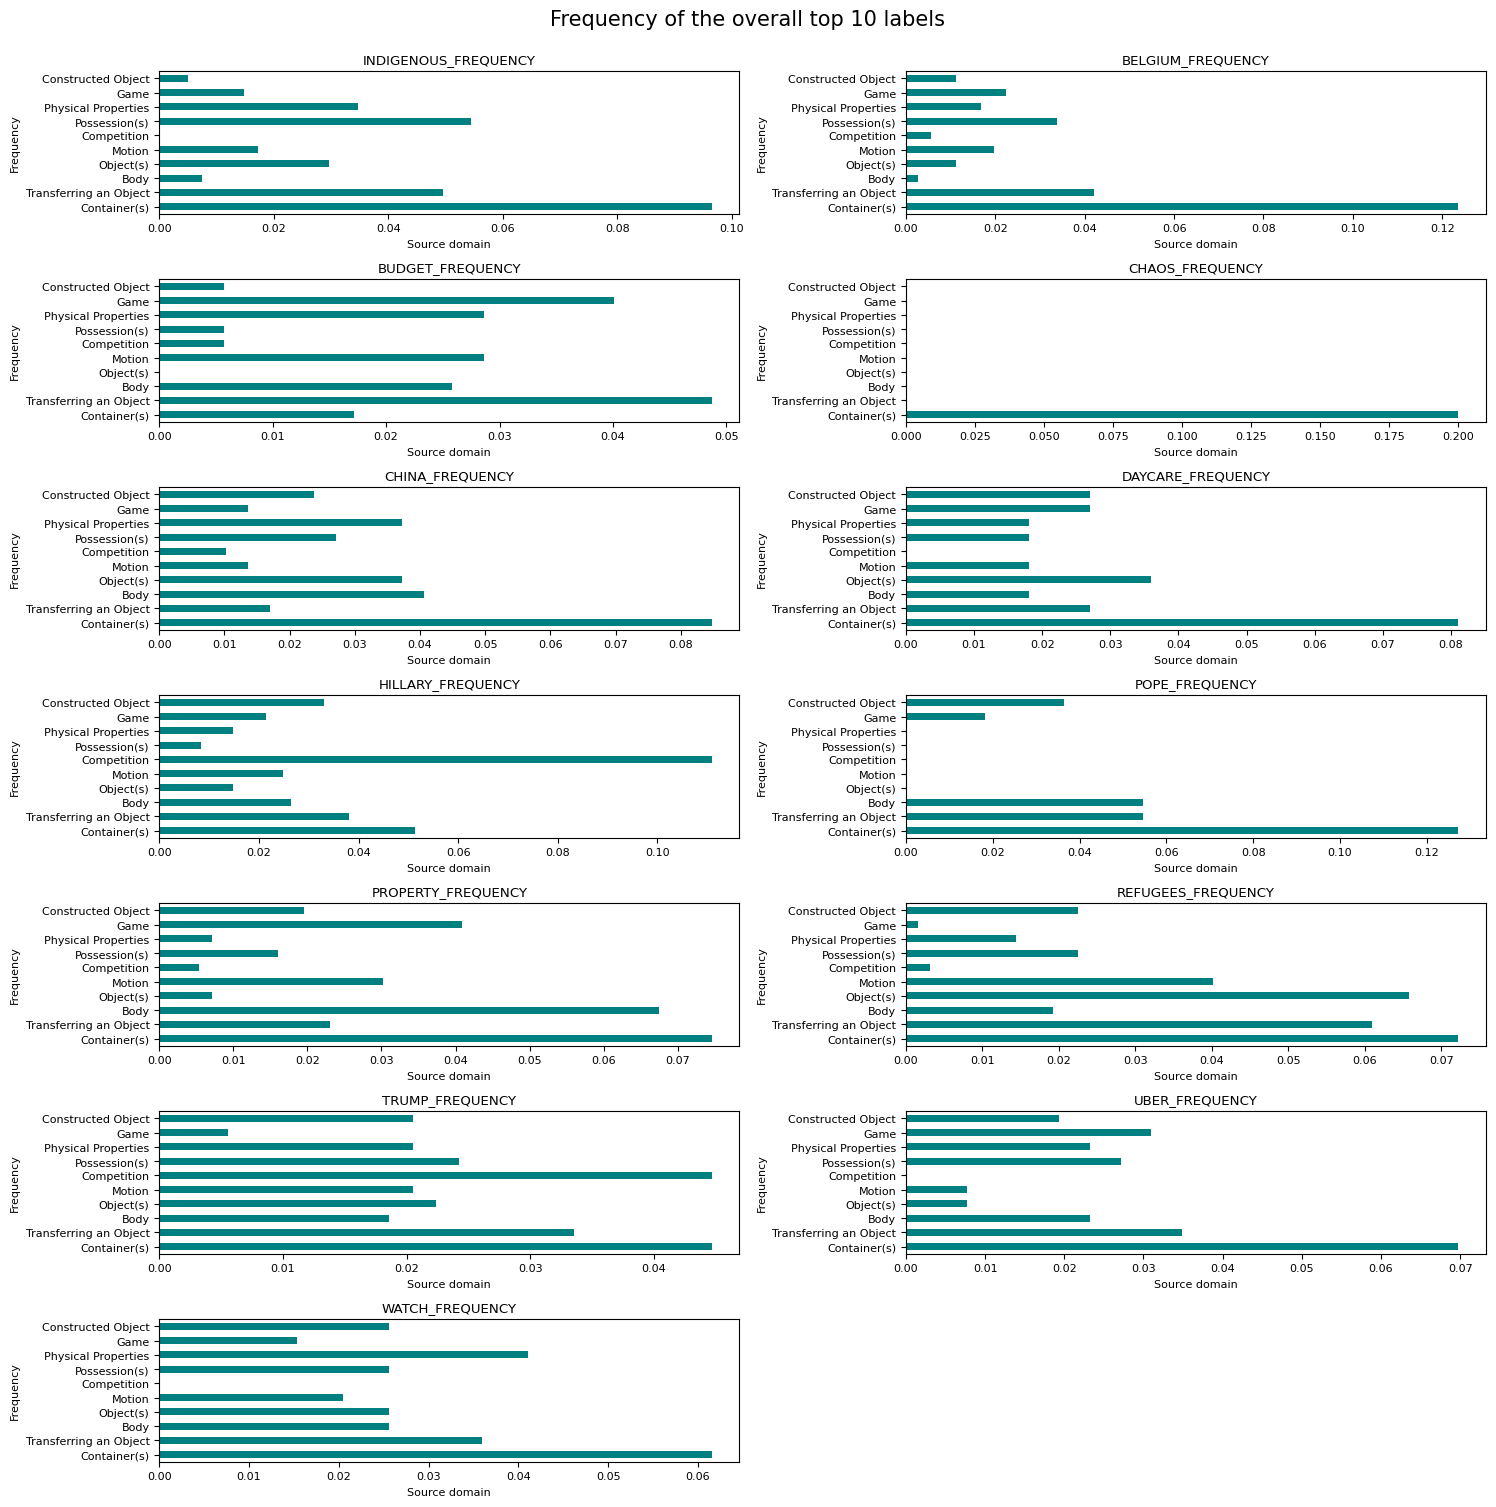

In [101]:
# plotting top 10 most common against frequency in each topic
plt.figure(figsize=(15, 15))
plt.rcParams.update({'font.size':8})
#plt.subplots_adjust(hspace=1.5)
plt.suptitle("Frequency of the overall top 10 labels", fontsize=15, y=1)

# loop through the length of tickers and keep track of index
for n, topic in enumerate(freq_columns):
    # add a new subplot iteratively
    ax = plt.subplot(7, 2, n + 1)

    # filter df and plot ticker on the new subplot axis
    top10.plot(x='label',y=topic,ax=ax, kind ='barh', color='teal')

    # chart formatting
    ax.set_title(topic.upper())
    ax.get_legend().remove()
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Source domain")
plt.tight_layout()
plt.savefig('overall_top10.png')

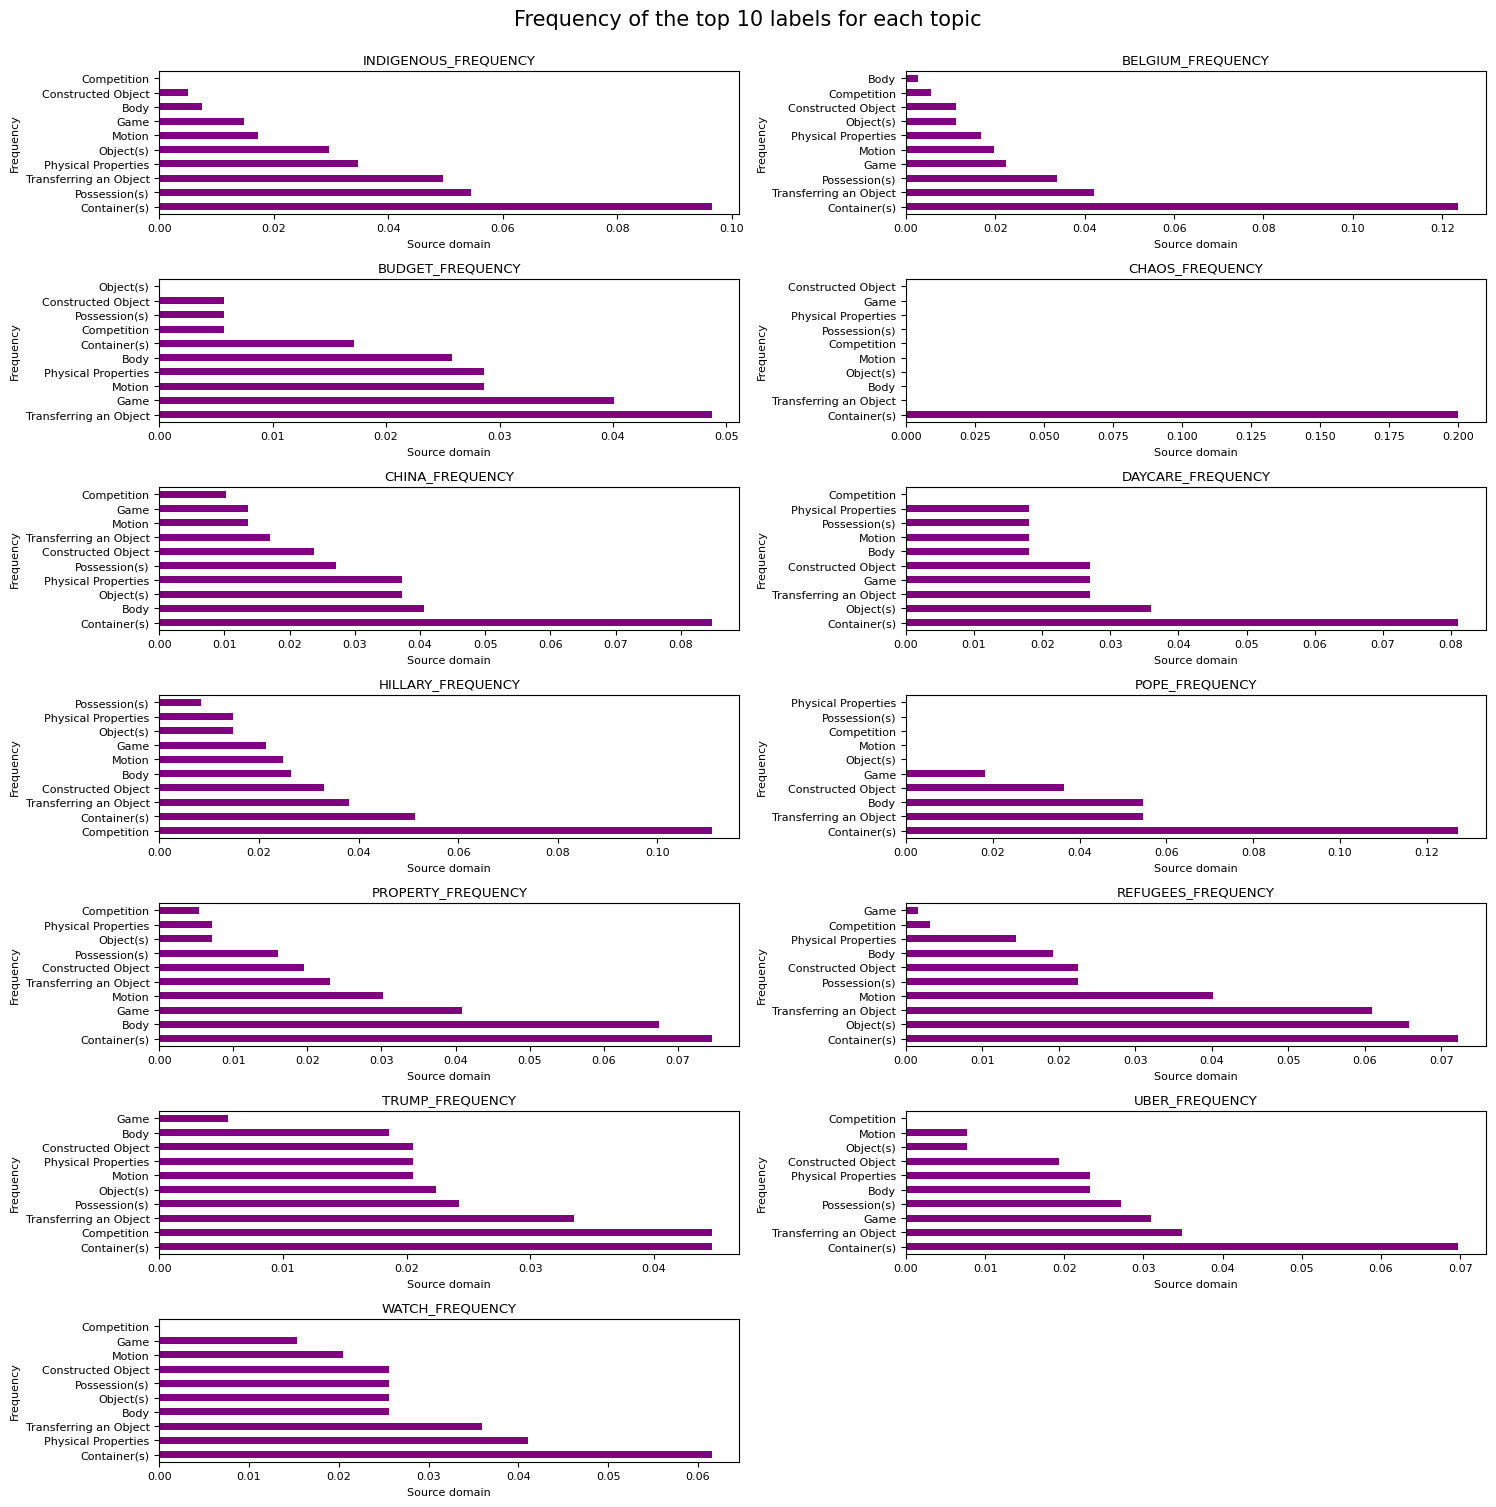

In [102]:
# plotting each topic's top 10 against and frequency
plt.figure(figsize=(15, 15))
plt.rcParams.update({'font.size':8})
#plt.subplots_adjust(hspace=1.5)
plt.suptitle("Frequency of the top 10 labels for each topic", fontsize=15, y=1)

# loop through the length of tickers and keep track of index
for n, topic in enumerate(freq_columns):
    # add a new subplot iteratively
    ax = plt.subplot(7, 2, n + 1)

    # filter df and plot ticker on the new subplot axis
    top10.sort_values(by=topic, ascending=False).head(10).plot(x='label',y=topic,ax=ax, kind ='barh', color='purple')

    # chart formatting
    ax.set_title(topic.upper())
    ax.get_legend().remove()
    ax.set_ylabel("Frequency")
    ax.set_xlabel("Source domain")
plt.tight_layout()
plt.savefig('per_topic_top10.png')